### 목표 : 프로 선수들의 플레이 스타일과 전투력이 latent space에서 어떻게 구조화되는가?
- 선수 representation 생성
- 플레이 스타일 구조 확인
- PCA component 해석
- robust feature 확인

#### Step 1. 모든 연도 데이터 합치기

In [2]:
import pandas as pd
import glob

files = glob.glob("processed/*_clean.csv")

dfs = []

for file in files:

    df = pd.read_csv(file)

    dfs.append(df)

data = pd.concat(
    dfs,
    ignore_index=True
)

#### Step 2. KDA랑 KP 생성
kill, death, assist는 서로 correlation이 커서 그냥 넣으면 단순 kill/death 분산에 끌려갈 수 있다.

In [6]:
data["kda"] = (
    (data["kills"] + data["assists"])
    / (data["deaths"] + 1)
)

data["kp"] = (
    (data["kills"] + data["assists"])
    / data["teamkills"].replace(0, 1)
)

#### Step 3. player-year representation 생성
일단 PCA를 사용할 수 있게 수치형 컬럼들만 골라내고, player-year로 representation 만듦.
그냥 데이터를 바로 사용하면 noise가 너무 크기 때문에 경기들을 평균내서 선수 representation을 생성하자.

In [7]:
numeric_features = [

    "golddiffat15",
    "xpdiffat15",
    "csdiffat15",

    "goldat15",
    "xpat15",
    "csat15",

    "kills",
    "deaths",
    "assists",

    "teamkills",

    "dpm",
    "damageshare",

    "damagetakenperminute",
    "damagemitigatedperminute",

    "visionscore",
    "vspm",

    "wardsplaced",
    "wardskilled",

    "wpm",
    "wcpm",

    "controlwardsbought",

    "earnedgold",
    "earned gpm",

    "earnedgoldshare",

    "cspm",

    "damagetotowers",

    "firstbloodkill",
    "firstbloodassist",
    "firstbloodvictim",

    "kda",
    "kp"
]

player_vectors = (
    data
    .groupby(
        [
            "playername",
            "year",
            "position"
        ]
    )[numeric_features]
    .mean()
    .reset_index()
)

#### Step 4. Standardizaion

In [8]:
from sklearn.preprocessing import StandardScaler

X = player_vectors[numeric_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#### Step 5. PCA 수행

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#### Step 6. 1차 latent space 시각화(서폿이랑 나머지 라인들을 구분해냄)

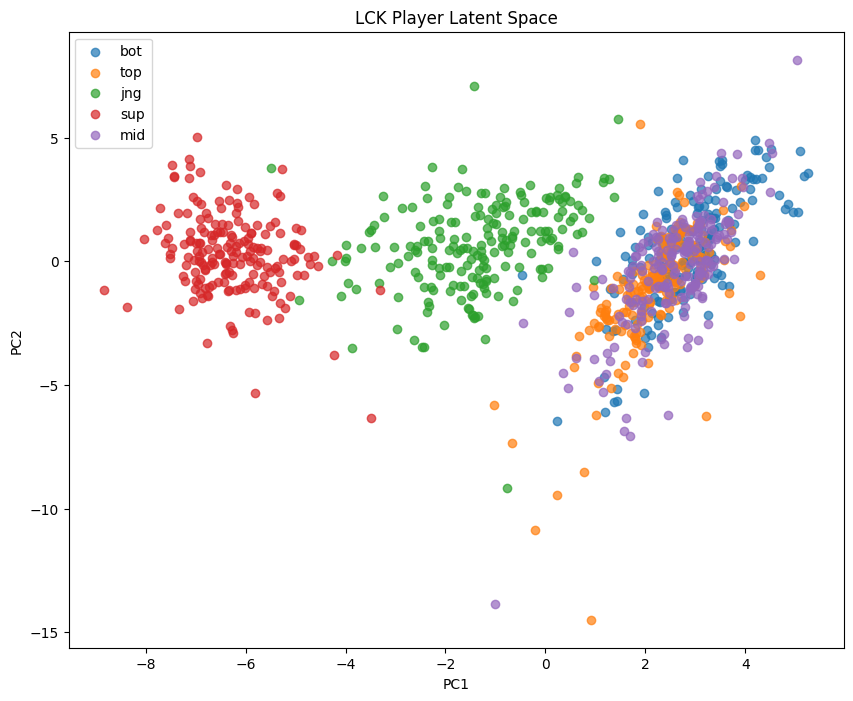

In [10]:
import matplotlib.pyplot as plt

positions = player_vectors["position"].unique()

plt.figure(figsize=(10,8))

for pos in positions:

    idx = (
        player_vectors["position"]
        == pos
    )

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=pos,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "LCK Player Latent Space"
)

plt.legend()

plt.show()

#### Step 7. PCA loading
->PCA1, PCA2가 각각 의미하는게 뭔데...

In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=numeric_features
)

print(loadings)

                               PC1       PC2
golddiffat15              0.011499  0.364221
xpdiffat15                0.014182  0.332164
csdiffat15                0.002328  0.295918
goldat15                  0.256994  0.071558
xpat15                    0.226645 -0.036408
csat15                    0.267704 -0.009971
kills                     0.208767  0.213017
deaths                   -0.082280 -0.179015
assists                  -0.141089  0.291083
teamkills                 0.018666  0.333036
dpm                       0.240718  0.101798
damageshare               0.257870 -0.003407
damagetakenperminute      0.023996  0.023137
damagemitigatedperminute -0.010401  0.053162
visionscore              -0.186216  0.138036
vspm                     -0.185745  0.134593
wardsplaced              -0.250693  0.052280
wardskilled              -0.126662  0.149591
wpm                      -0.254146  0.052786
wcpm                     -0.132912  0.159864
controlwardsbought       -0.244205  0.060229
earnedgold

### MID 선수들의 latent playstyle 분석

In [26]:
mid_data = player_vectors[
    player_vectors["position"] == "mid"
].copy()

#### Step 1. 미드 선수들 뽑아내기

In [27]:
print(mid_data.shape)

print(
    mid_data["playername"].unique()[:10]
)

(197, 34)
<StringArray>
[   'Aria',  'Athena',     'Bay',     'Bdd',   'Blanc', 'BuLLDoG',   'Calix',
  'Callme',   'Candy',  'Canyon']
Length: 10, dtype: str


#### Step 2. MID feature matrix 생성

In [28]:
X_mid = mid_data[numeric_features]

#### STEP 3. Standardization

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_mid_scaled = scaler.fit_transform(X_mid)

#### STEP 4. MID 전용 PCA

In [30]:
from sklearn.decomposition import PCA

pca_mid = PCA(n_components=2)

X_mid_pca = pca_mid.fit_transform(
    X_mid_scaled
)

#### STEP 5. PCA 좌표 dataframe 생성

In [31]:
mid_data["PC1"] = X_mid_pca[:,0]
mid_data["PC2"] = X_mid_pca[:,1]

#### STEP 6. MID latent space 시각화

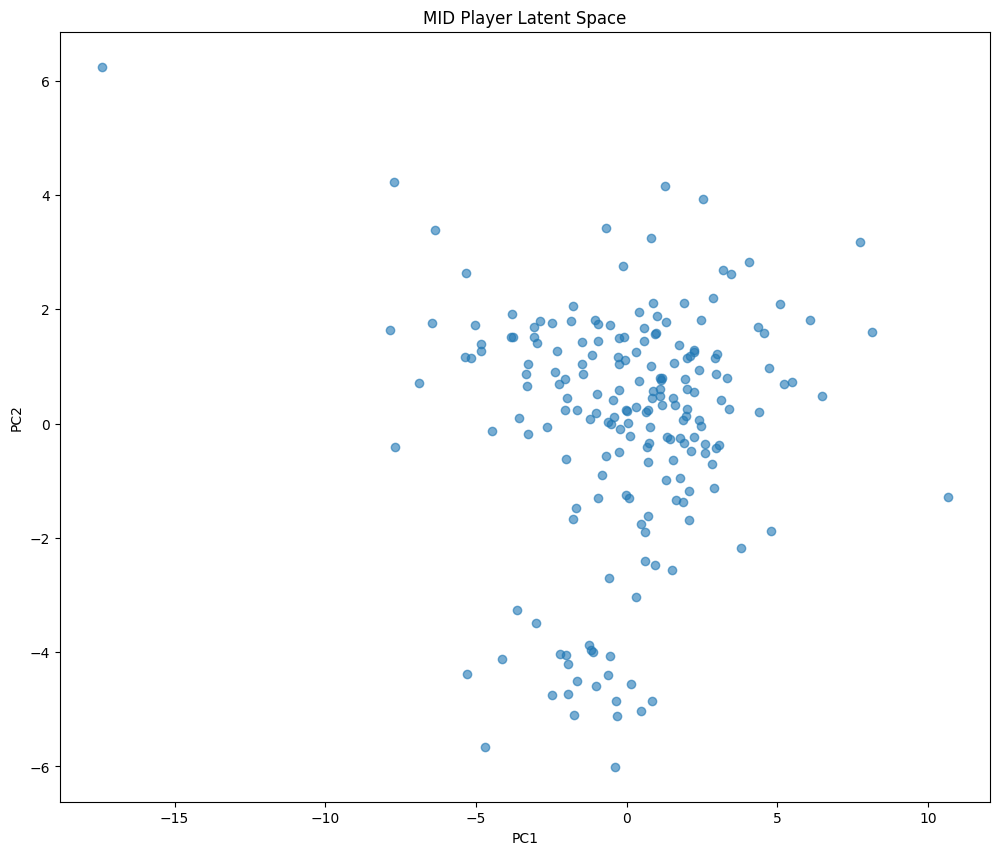

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.scatter(
    mid_data["PC1"],
    mid_data["PC2"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "MID Player Latent Space"
)

plt.show()

#### STEP 7. MID PCA loading 분석

In [36]:
import pandas as pd

loadings_mid = pd.DataFrame(
    pca_mid.components_.T,
    columns=["PC1", "PC2"],
    index=numeric_features
)
print(
    loadings_mid.sort_values(
        by="PC1",
        ascending=False
    )
)

                               PC1       PC2
earned gpm                0.296467 -0.025078
goldat15                  0.284037  0.036299
golddiffat15              0.264792 -0.143448
kills                     0.253770 -0.021119
csdiffat15                0.250527 -0.130599
xpdiffat15                0.244313 -0.120744
teamkills                 0.233432  0.082677
csat15                    0.231847  0.094416
kda                       0.229695 -0.040918
xpat15                    0.227669  0.096880
cspm                      0.225151 -0.033754
dpm                       0.222046  0.008963
damagetotowers            0.221227  0.274603
assists                   0.213164  0.053497
earnedgold                0.209978 -0.229699
earnedgoldshare           0.142248 -0.130472
damageshare               0.135746 -0.242519
kp                        0.133688 -0.188075
visionscore               0.106336  0.346058
vspm                      0.099517  0.378598
firstbloodkill            0.090576 -0.064228
damagemiti

#### 예시로 faker만 분석

In [23]:
faker_data = mid_data[
    mid_data["playername"] == "Faker"
]

In [24]:
faker_data = faker_data.sort_values(
    by="year"
)
print(
    faker_data[
        [
            "year",
            "PC1",
            "PC2"
        ]
    ]
)

     year       PC1       PC2
272  2016  0.835993 -4.862771
273  2017  2.086289 -1.680544
274  2018  2.592627 -0.362641
275  2019  1.542592  0.451191
276  2020  2.419901  0.069935
277  2021  0.878890  0.563292
278  2022  1.109274  0.796151
279  2023  0.961543  1.573730
280  2024  3.346879  0.795334
281  2025  1.309972  1.782509
282  2026  2.547999  3.928233


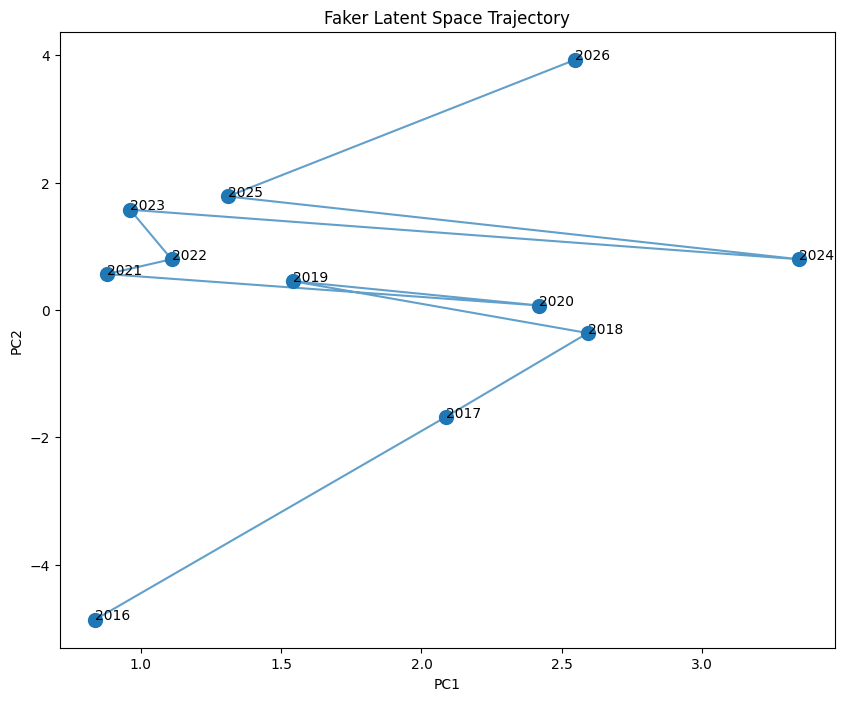

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

# 점 찍기
plt.scatter(
    faker_data["PC1"],
    faker_data["PC2"],
    s=100
)

# 선 연결
plt.plot(
    faker_data["PC1"],
    faker_data["PC2"],
    alpha=0.7
)

# 연도 표시
for _, row in faker_data.iterrows():

    plt.text(
        row["PC1"],
        row["PC2"],
        str(row["year"]),
        fontsize=10
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Faker Latent Space Trajectory"
)

plt.show()


### JGL 선수들의 Latent playstyle 분석

### Step 1. 정글 데이터만 추출

In [37]:
jng_data = player_vectors[
    player_vectors["position"] == "jng"
].copy()

#### Step 2. PCA 가능하게 Numeric Features만 추출

In [38]:
X_jng = jng_data[numeric_features]

#### Step 3. Standardization

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_jng_scaled = scaler.fit_transform(
    X_jng
)

#### Step 4. PCA 수행

In [ ]:
from sklearn.decomposition import PCA

pca_jng = PCA(n_components=2)

X_jng_pca = pca_jng.fit_transform(
    X_jng_scaled
)

#### STEP 5. PCA 좌표 dataframe 생성

In [41]:
jng_data["PC1"] = X_jng_pca[:,0]
jng_data["PC2"] = X_jng_pca[:,1]

#### Step 6. JGL latent space 시각화

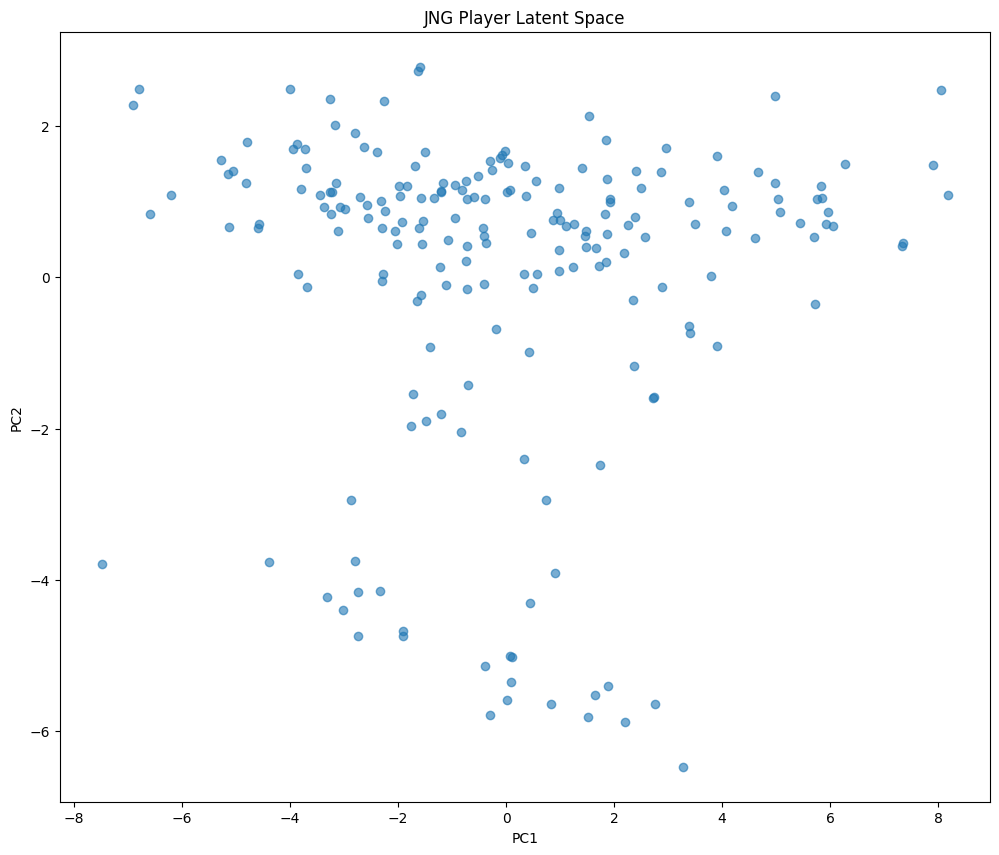

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.scatter(
    jng_data["PC1"],
    jng_data["PC2"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "JNG Player Latent Space"
)

plt.show()

#### Step 7. JGL PCA loading 분석

In [44]:
import pandas as pd

loadings_jng = pd.DataFrame(
    pca_jng.components_.T,
    columns=["PC1", "PC2"],
    index=numeric_features
)
print(
    loadings_jng.sort_values(
        by="PC1",
        ascending=False
    )
)

                               PC1       PC2
dpm                       0.283970 -0.063030
goldat15                  0.282195 -0.011629
earned gpm                0.279769 -0.124589
kills                     0.263771 -0.033947
xpat15                    0.248467 -0.118535
teamkills                 0.247859  0.068700
cspm                      0.234596  0.187385
earnedgoldshare           0.223217 -0.248491
csat15                    0.217656  0.267875
damagetakenperminute      0.213973  0.089060
assists                   0.200641  0.095471
damageshare               0.194653 -0.200251
damagetotowers            0.191890  0.255357
kda                       0.187538  0.014573
earnedgold                0.167692 -0.242714
golddiffat15              0.155384 -0.100008
xpdiffat15                0.141978 -0.099618
damagemitigatedperminute  0.119875  0.404030
csdiffat15                0.111883 -0.089731
firstbloodkill            0.071940 -0.024338
kp                        0.035283  0.004825
deaths    